# Pmode Gaussian gates


<div class="note"><span class="note-t">TL;DR</span>
<p>We propagate a pmode's mean and covariance exactly through affine Gaussian stacks, while <code>MixtureGaussianGate</code> introduces discrete control and a non-Gaussian density. We check every gate with point clouds, analytic moments, and closed-form conditioning.</p>
</div>

In this tutorial, we build Torx's continuous **pmode** gate set and check it from a few angles.

The pmode is Torx's continuous data primitive. A pmode site has a value in $\mathbb{R}^N$, and we track its mean and covariance. The gates in this tutorial act on pmode sites.

The most general gate is `AffineGaussianGate`. It takes a point, applies a linear map, adds a bias, and adds Gaussian noise. The specialized gates `Displace`, `Scale`, `Mix`, and `Diffuse` cover common choices of those parameters.

A Gaussian stays Gaussian under this map, so it is enough to carry the mean and covariance through the circuit and let each gate update those two moments directly.

By the end, you'll be able to:

- build the gate set and watch each gate deform a point cloud,
- propagate moments exactly with `AffineGaussianSimulator` and check them against Monte Carlo samples,
- condition the joint distribution on one site in closed form, and
- use `MixtureGaussianGate` with a discrete control to leave the Gaussian family.

These same primitives drive the linear-Gaussian state-space model (SSM) of [`11_gaussian_hierarchical_ssm.ipynb`](11_gaussian_hierarchical_ssm.ipynb) and the regime-switching diffusion process of [`13_regime_switching_diffusion.ipynb`](13_regime_switching_diffusion.ipynb); [`12_langevin_graph_ising.ipynb`](12_langevin_graph_ising.ipynb) builds a custom nonlinear Langevin gate on the same continuous pmode site.



## Setup

We import Torx, JAX, and the notebook plotting helpers, then apply the shared figure style.

The specialized gates `Displace`, `Scale`, `Mix`, and `Diffuse` are public `torx.psc` gates, imported here alongside the general `AffineGaussianGate`.

In [1]:
from pathlib import Path
import sys

import equinox as eqx
import jax
import jax.numpy as jnp
import numpy as np

ROOT = Path.cwd()
if not (ROOT / "helpers").exists() and (ROOT.parent / "helpers").exists():
    ROOT = ROOT.parent
HELPER_DIR = ROOT / "helpers"
sys.path.insert(0, str(HELPER_DIR))



In [2]:
from _notebook_paths import figure_dir
from _notebook_style import apply_notebook_style, make_savefig
import _plots_schematics as P_sch
import _plots_fields as P_fld
import _plots_sampling as P_samp
from torx.psc import (
    AffineGaussianGate,
    AffineGaussianSimulator,
    Diffuse,
    Displace,
    HybridPCircuit,
    Mix,
    MixtureGaussianGate,
    PditShift,
    Scale,
)



In [3]:
apply_notebook_style()
FIGURE_DIR = figure_dir(ROOT)

SEED = 12


savefig = make_savefig(FIGURE_DIR)

The next helpers sample a gate on many input points and compare empirical moments with analytic ones.

In [4]:
def _sample_gate_cloud(gate, theta, cloud, seed):
    """Sample one continuous gate over a point cloud (vmapped)."""
    cloud_j = jnp.asarray(cloud, dtype=jnp.float32)
    keys = jax.random.split(jax.random.key(seed), cloud_j.shape[0])
    out = _sample_gate_cloud_jit(gate, theta, cloud_j, keys)
    return np.asarray(out)




In [5]:
@eqx.filter_jit
def _sample_gate_cloud_jit(gate, theta, cloud_j, keys):
    """Push every point of `cloud_j` through one gate sample, batched under jit."""
    no_control = jnp.array([], dtype=jnp.int32)

    def sample_one(x, key):
        return gate.sample(key, {"discrete": no_control, "continuous": x}, theta)

    return jax.vmap(sample_one)(cloud_j, keys)




In [6]:
def _mean_cov(points):
    """Sample mean and covariance of a point cloud."""
    return points.mean(axis=0), np.cov(points, rowvar=False)




In [7]:
def _assert_mean_cov_close(
    points, expected_mean, expected_cov, label, *, mean_atol=0.08, cov_atol=0.12
):
    """Check sampled moments against analytic ones and fail loudly past tolerance."""
    mean, cov = _mean_cov(points)
    mean_err = float(np.max(np.abs(mean - expected_mean)))
    cov_err = float(np.max(np.abs(cov - expected_cov)))
    print(f"{label}: mean err {mean_err:.4f}, cov err {cov_err:.4f}")
    if mean_err >= mean_atol:
        raise AssertionError(f"{label} mean error {mean_err:.4f} >= {mean_atol}")
    if cov_err >= cov_atol:
        raise AssertionError(f"{label} covariance error {cov_err:.4f} >= {cov_atol}")




In [8]:
def _sample_site0_gate(gate, theta, cloud, seed):
    """Sample a scalar continuous gate on site 0 and splice it back into a 2D cloud."""
    next_cloud = cloud.copy()
    next_cloud[:, 0] = _sample_gate_cloud(gate, theta, cloud[:, :1], seed)[:, 0]
    return next_cloud


## The gate set

Here is the full affine Gaussian gate. It maps a point $x$ to a new point $x'$:

$$
x' = \underbrace{M x}_{\vphantom{\big|}\text{linear map}} + \mathbf{d} + \varepsilon,
$$

where $\mathbf{d}$ is the bias displacement and $\varepsilon \sim \mathcal{N}(0,\, \Delta)$ is diagonal Gaussian noise. In code, the linear map $M$ and bias $\mathbf{d}$ are the `A` and `b` keys of the gate's `theta`, and $\Delta = \operatorname{diag}(\exp(\texttt{log_var}))$.

A Gaussian input remains Gaussian under this map, so the gate can update the mean and covariance directly:

$$
\mu \mapsto M\mu + \mathbf{d}, \qquad \Sigma \mapsto \underbrace{M\Sigma M^\top}_{\vphantom{\big|}\text{covariance}} + \Delta .
$$

The mean transforms affinely. The diagonal noise covariance $\Delta$ adds straight into $\Sigma$; correlated covariance can come through the $M\Sigma M^\top$ term.

Gates compose by the affine composition law:

$$
(M_2, \mathbf{d}_2, \Delta_2) \circ (M_1, \mathbf{d}_1, \Delta_1)
= (M_2 M_1,\ M_2 \mathbf{d}_1 + \mathbf{d}_2,\ M_2 \Delta_1 M_2^\top + \Delta_2),
$$

so a stack of gates is itself one affine Gaussian map. The named gates choose specific parameters:

| Gate | $M$ | $\mathbf{d}$ | $\Delta$ | Action |
|------|---|---|---------|--------|
| `AffineGaussianGate` | any | any | diag | general affine map and diagonal noise |
| `Displace` ($\theta = \alpha$) | $I$ | $\alpha$ | $0$ | shift |
| `Scale` ($\theta = r$) | $\mathrm{diag}(e^r)$ | $0$ | $0$ | exponential scale |
| `Mix` ($\theta$) | $R(\theta)$ | $0$ | $0$ | rotate two sites |
| `Diffuse` ($\theta = \log(2 D\, dt)$) | $I$ | $0$ | $2 D\, dt\, I$ | Brownian diffusion |

`Displace`, `Scale`, and `Mix` are deterministic affine-Gaussian channels (no added noise); `Diffuse` is the additive Brownian-noise channel. All four are public `torx.psc` gates that specialize `AffineGaussianGate`.

The next example uses a shear-rotation with anisotropic diagonal noise (spread differs by direction), which none of the specialized gates produce alone.


In [9]:
theta_rad = 0.20
c_, s_ = np.cos(theta_rad), np.sin(theta_rad)
# Compose a small rotation with a shear to make a nontrivial linear map.
A_demo = (np.array([[c_, -s_], [s_, c_]]) @ np.array([[1.0, 0.40], [0.0, 1.0]])).astype(
    np.float32
)
b_demo = np.array([0.05, -0.10], dtype=np.float32)
log_var_demo = np.array([np.log(0.02), np.log(0.20)], dtype=np.float32)
var_demo = np.exp(log_var_demo)

In [10]:
affine_demo = AffineGaussianGate(sites=[0, 1], dims=(1, 1))
affine_demo_theta = {
    "A": jnp.asarray(A_demo),
    "b": jnp.asarray(b_demo),
    "log_var": jnp.asarray(log_var_demo),
}

Now we sample the gate over a standard-normal input cloud.

In [11]:
rng_demo = np.random.default_rng(SEED + 99)
in_cloud = rng_demo.standard_normal((1500, 2)).astype(np.float32)
out_cloud = _sample_gate_cloud(affine_demo, affine_demo_theta, in_cloud, SEED + 1000)

In [12]:
in_mean, in_cov = _mean_cov(in_cloud)
expected_mean = A_demo @ in_mean + b_demo
# The analytic covariance is the pushed-forward input covariance plus gate noise.
expected_cov = A_demo @ in_cov @ A_demo.T + np.diag(var_demo)
_assert_mean_cov_close(
    out_cloud, expected_mean, expected_cov, "AffineGaussianGate sample"
)

AffineGaussianGate sample: mean err 0.0223, cov err 0.0486


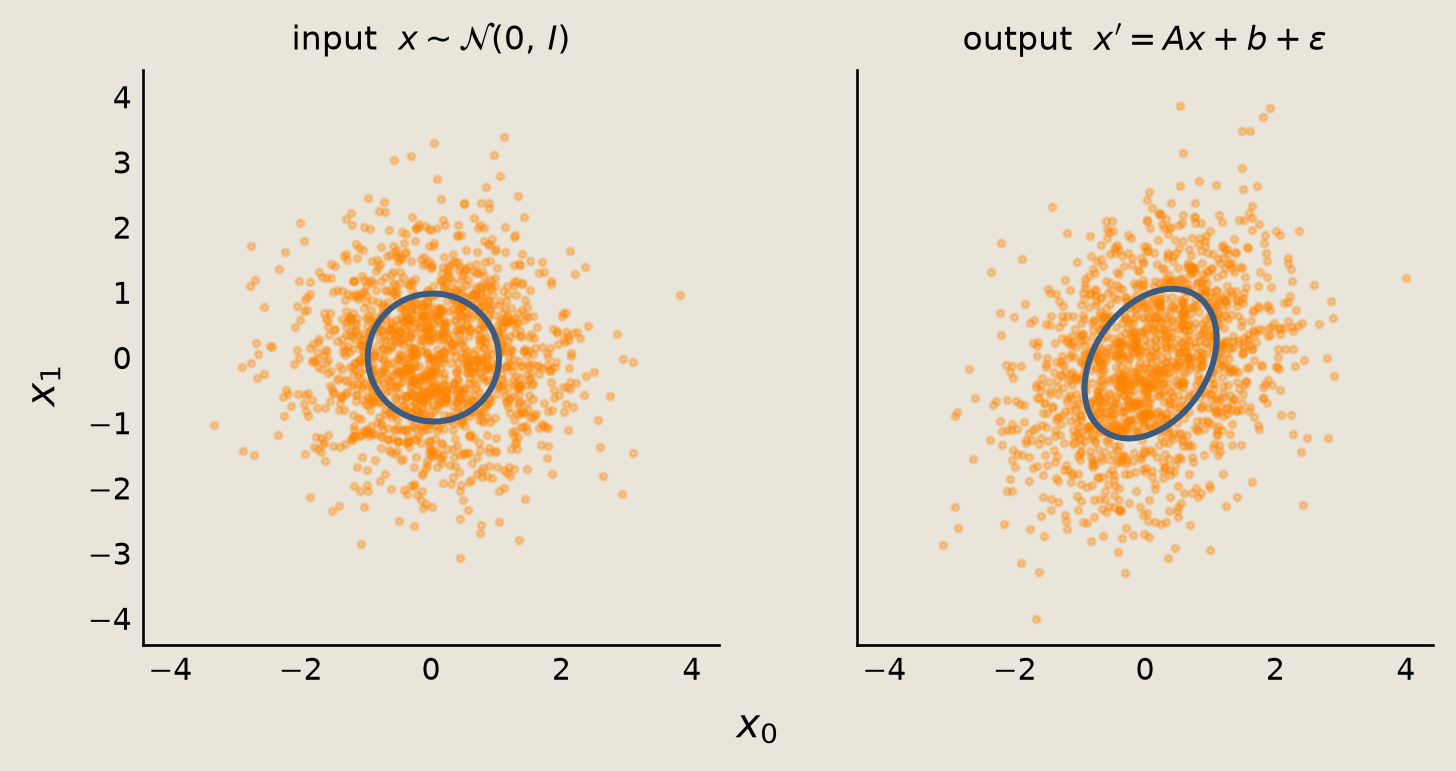

In [13]:
fig = P_fld.affine_general_clouds(
    in_cloud, out_cloud, expected_mean, expected_cov, figsize=(6.2, 3.1)
)
savefig(fig, "10_affine_gaussian_general")

The one-sigma contour aligns with the sampled density: the central mass of the cloud follows the exact contour. The moment update captures the shear-rotation and anisotropic noise without enumerating the cloud.

The named constructors make common affine Gaussian transformations explicit. Each gate stores the sites it acts on; its numeric parameters live in separate `theta` arrays. A `HybridPCircuit` then composes the four gates into one layer that repeats four times.

In [14]:
dt = 0.4
# Structure-only public gates; their parameters live in theta arrays.
diff_gate = Diffuse(sites=0, dims=(1,))
disp_gate = Displace(sites=0, dims=(1,))
scale_gate = Scale(sites=0, dims=(1,))
mix_gate = Mix(sites=[0, 1], dims=(1, 1))



In [15]:
diff_theta_stack = jnp.log(jnp.array([2.0 * 0.25 * dt]))  # log-variance log(2 D dt)
disp_theta_stack = jnp.array([0.17])  # displacement b
scale_theta_stack = jnp.log(jnp.array([1.10]))  # log-scale
mix_angle_stack = jnp.asarray(0.35)  # rotation angle



In [16]:
step = HybridPCircuit(
    [diff_gate, disp_gate, scale_gate, mix_gate],
    reps=4,
)
# Per-gate parameters, aligned with step.gates.
step_thetas = [diff_theta_stack, disp_theta_stack, scale_theta_stack, mix_angle_stack]


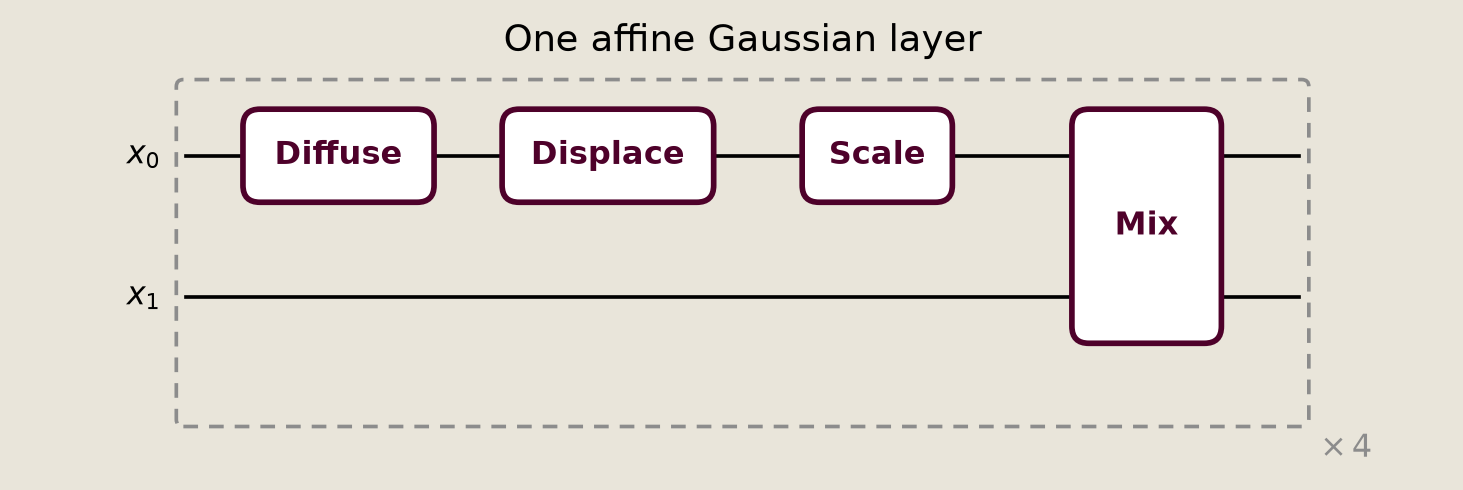

In [17]:
fig = P_sch.draw_pcircuit(
    [("Diffuse", [0]), ("Displace", [0]), ("Scale", [0]), ("Mix", [0, 1])],
    wire_labels=[r"$x_0$", r"$x_1$"],
    title="One affine Gaussian layer",
    reps=4,
    figsize=(6.2, 2.2),
)
savefig(fig, "10_pmode_layer_circuit")

Each repetition reuses the same four-gate layer. The whole stack still composes to one affine Gaussian map.

### The effect of each gate

Each named gate changes one part of the moments.

`Diffuse` adds to $\Sigma$, so it broadens the cloud along $x_0$. `Displace` adds to $\mu$, so it shifts. `Scale` multiplies site 0, so it stretches along $x_0$. `Mix` rotates the two sites, so it correlates them.

To see those effects separately, we apply each gate to the same input cloud and check the sampled moments against each gate's analytic update; the print reports the largest mean and covariance errors. The figure then shows the moment change panel by panel.

In [18]:
N_CLOUD = 3000
# An elongated input cloud so every gate's effect is visible, including the
# Mix rotation (a rotation does nothing to an isotropic cloud).
input_scale = np.array([1.45, 0.72])
diffusion = 2.1  # adds 2 * diffusion * dt to the x0 variance
disp_alpha = 2.6  # shifts the x0 mean
scale_r = float(jnp.log(1.9))  # stretches x0 by e^r
mix_angle = 0.62  # rotates the two sites into correlation

diff_theta_panel = jnp.log(jnp.array([2.0 * diffusion * dt]))
disp_theta_panel = jnp.array([disp_alpha])
scale_theta_panel = jnp.array([scale_r])
mix_angle_panel = jnp.asarray(mix_angle)


In [19]:
rng = np.random.default_rng(SEED)
cloud0 = (rng.standard_normal((N_CLOUD, 2)) * input_scale).astype(np.float32)
mu0, cov0 = _mean_cov(cloud0)



In [20]:
# Diffuse only changes the variance of the acted-on site.
diff_cloud = _sample_site0_gate(diff_gate, diff_theta_panel, cloud0, SEED + 10)
exp_cov = cov0.copy()
exp_cov[0, 0] += 2 * diffusion * dt
_assert_mean_cov_close(diff_cloud, mu0, exp_cov, "Diffuse", cov_atol=0.20)

disp_cloud = _sample_site0_gate(disp_gate, disp_theta_panel, cloud0, SEED + 11)
_assert_mean_cov_close(
    disp_cloud,
    mu0 + np.array([disp_alpha, 0.0]),
    cov0,
    "Displace",
)

scale_cloud = _sample_site0_gate(scale_gate, scale_theta_panel, cloud0, SEED + 12)
scale_mat = np.diag([np.exp(scale_r), 1.0])
_assert_mean_cov_close(
    scale_cloud,
    scale_mat @ mu0,
    scale_mat @ cov0 @ scale_mat.T,
    "Scale",
    cov_atol=0.35,
)

cos_t, sin_t = np.cos(mix_angle), np.sin(mix_angle)
rot_mat = np.array([[cos_t, -sin_t], [sin_t, cos_t]])
mix_cloud = _sample_gate_cloud(mix_gate, mix_angle_panel, cloud0, SEED + 13)
_assert_mean_cov_close(
    mix_cloud,
    rot_mat @ mu0,
    rot_mat @ cov0 @ rot_mat.T,
    "Mix",
)

Diffuse: mean err 0.0324, cov err 0.1700
Displace: mean err 0.0000, cov err 0.0000
Scale: mean err 0.0000, cov err 0.0000


Mix: mean err 0.0000, cov err 0.0000


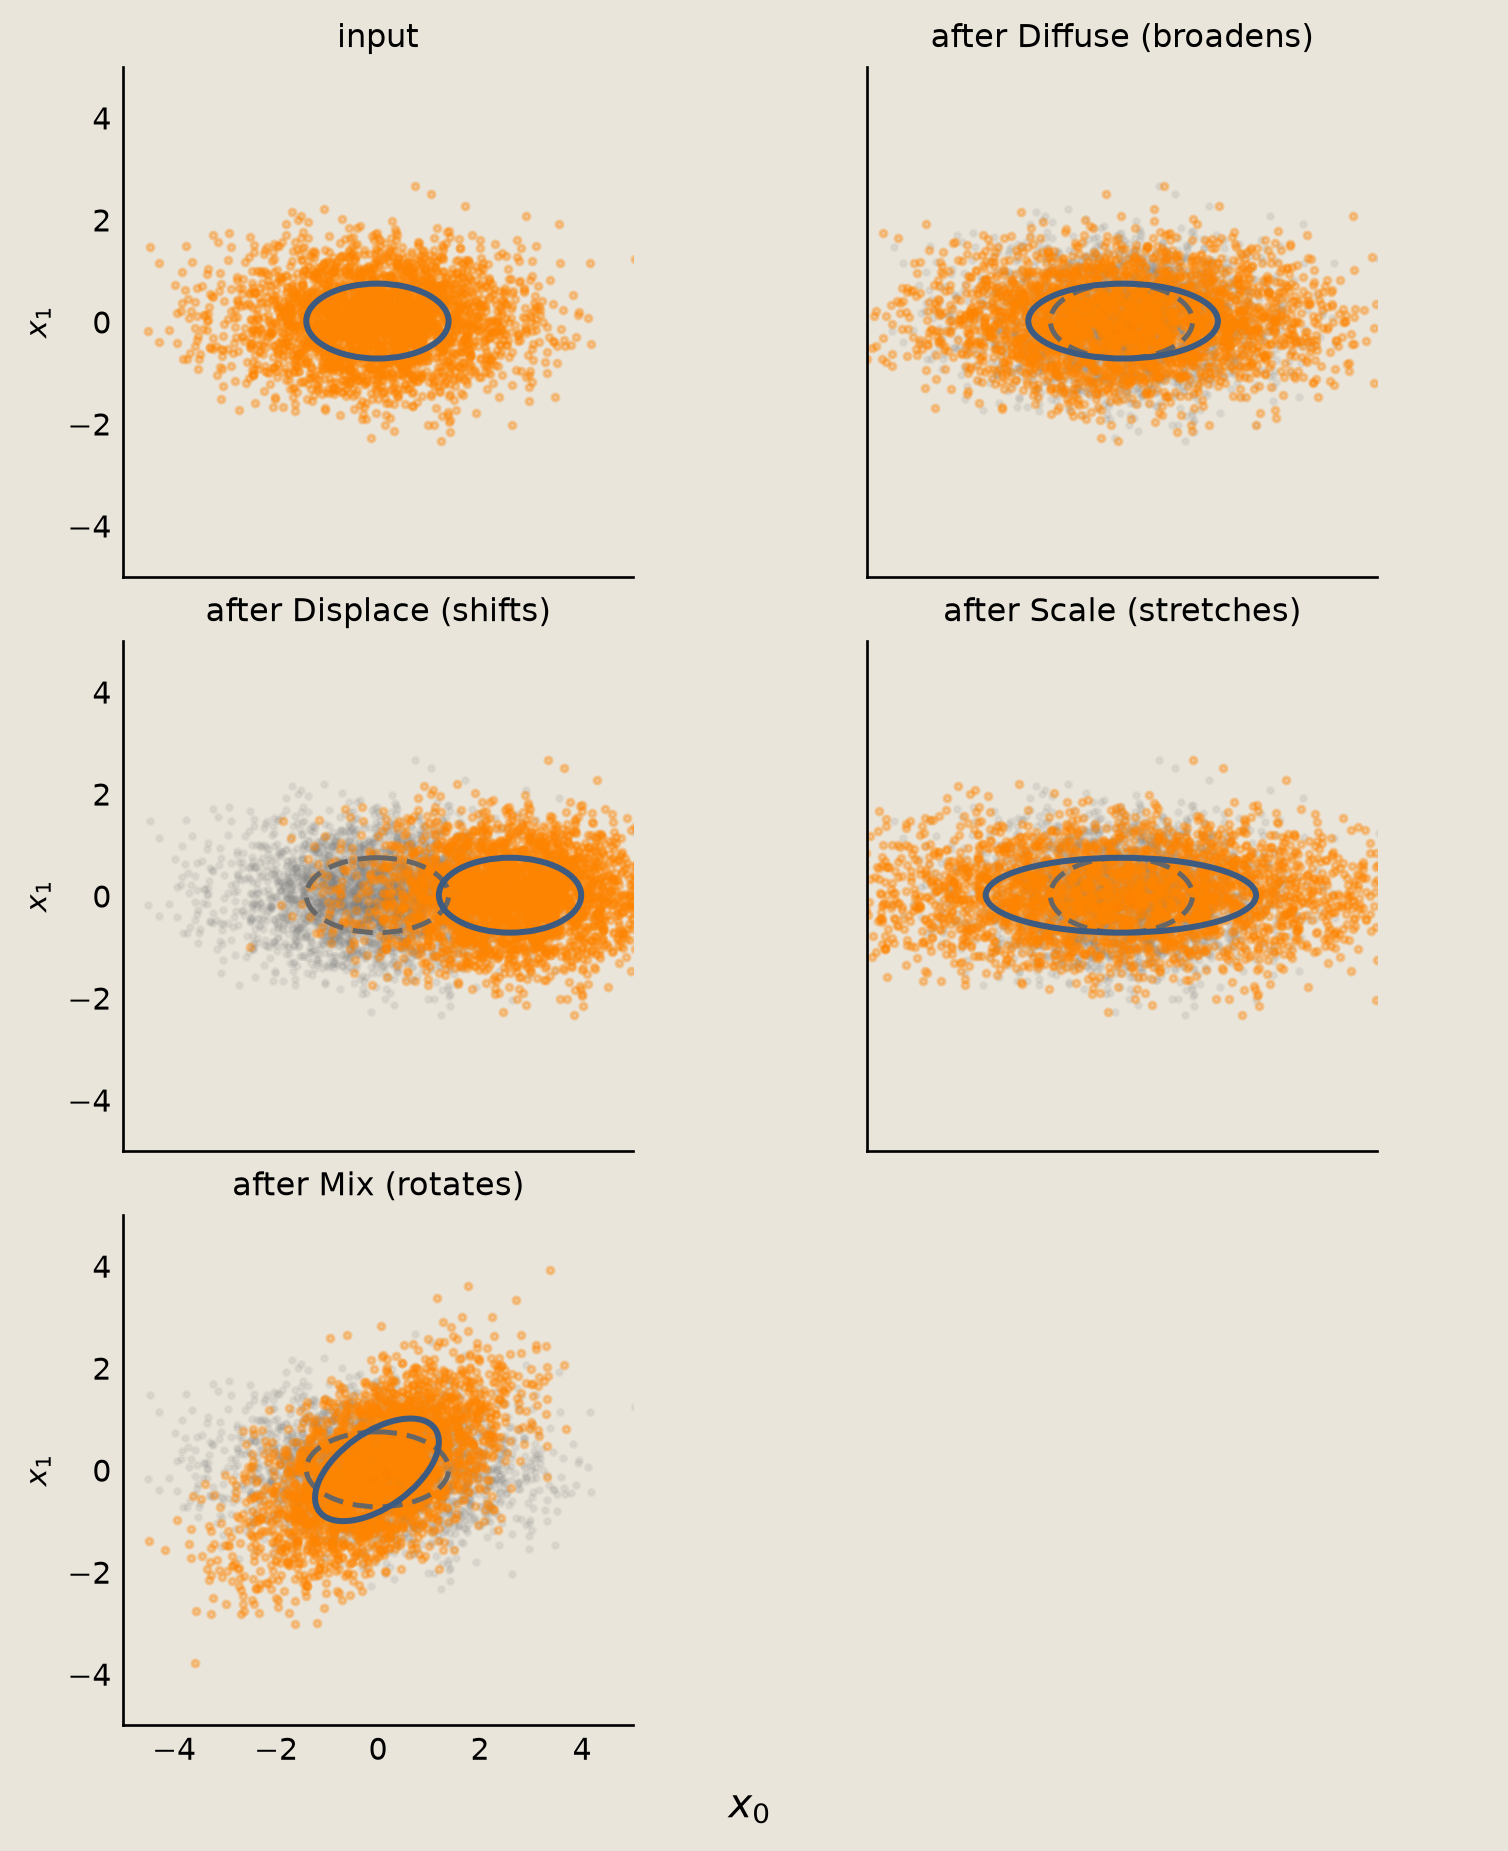

In [21]:
panels = [
    ("input", cloud0, None),
    ("after Diffuse (broadens)", diff_cloud, cloud0),
    ("after Displace (shifts)", disp_cloud, cloud0),
    ("after Scale (stretches)", scale_cloud, cloud0),
    ("after Mix (rotates)", mix_cloud, cloud0),
]
fig = P_fld.gate_sequence_clouds(panels, figsize=(6.2, 7.6))
savefig(fig, "10_pmode_gate_sequence")

Each panel deforms the same input cloud, shown faintly with a dashed ellipse, as its moment update predicts: broaden, shift, stretch, and tilt into correlation.

## Exact moment propagation

Sampling clouds is a useful sanity check on the gates, but because a stack of affine Gaussian gates is still one affine Gaussian map, we can carry the moments forward without drawing samples.

`AffineGaussianSimulator` propagates the mean and covariance analytically through the composed map. For a Gaussian, those two moments determine the density.

In [22]:
affine_sim = AffineGaussianSimulator()
affine_compiled = affine_sim.build_circuit(step, step_thetas)

In [23]:
prior = affine_sim.propagate(affine_compiled, jnp.zeros(2))

print(f"prior mean:       {np.array(prior.mean).tolist()}")
print("prior covariance:")
print(np.array(prior.covariance))

prior mean:       [0.5207920670509338, 0.5835674405097961]
prior covariance:
[[0.5202335  0.46302444]
 [0.46302444 0.67771125]]


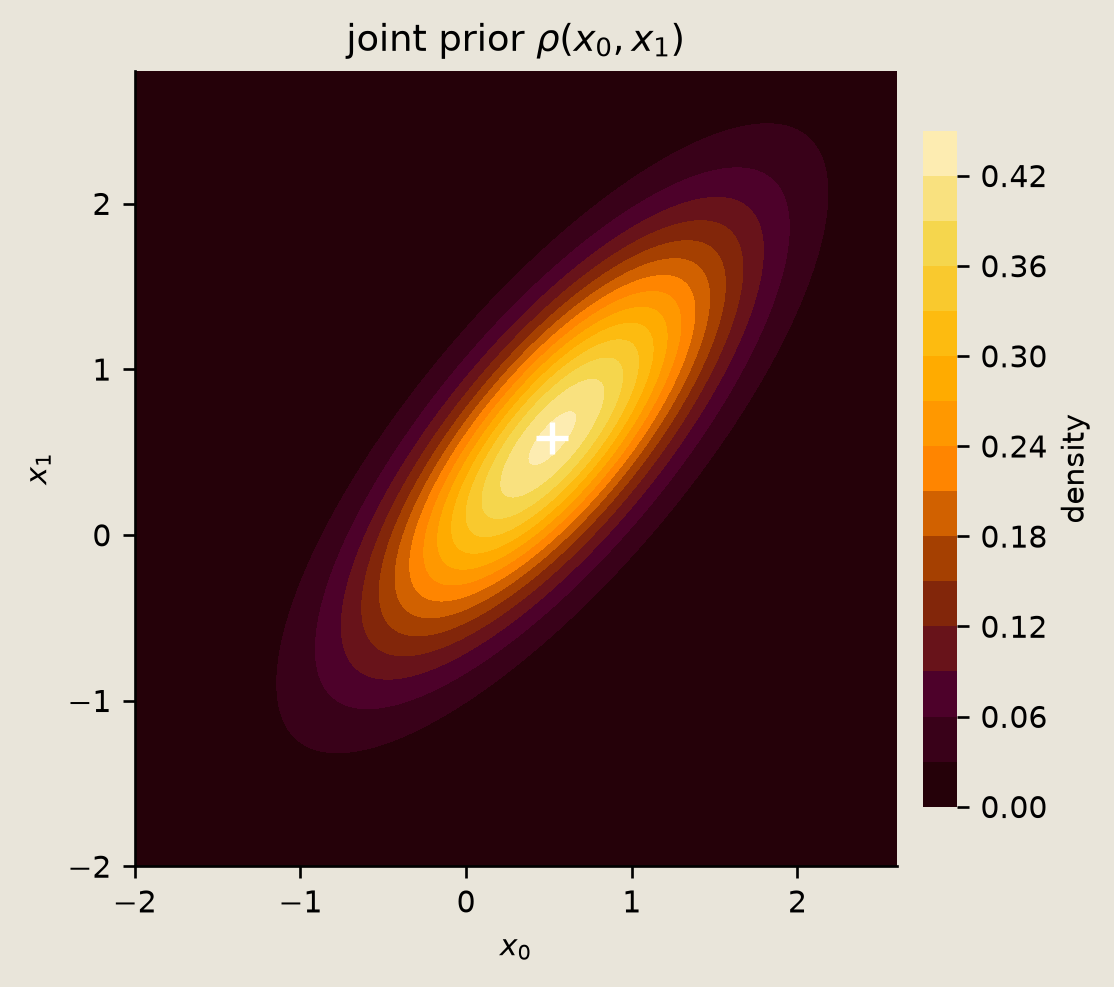

In [24]:
fig = P_fld.prior_joint_density(prior, figsize=(4.6, 4.0))
savefig(fig, "10_pmode_prior_density")

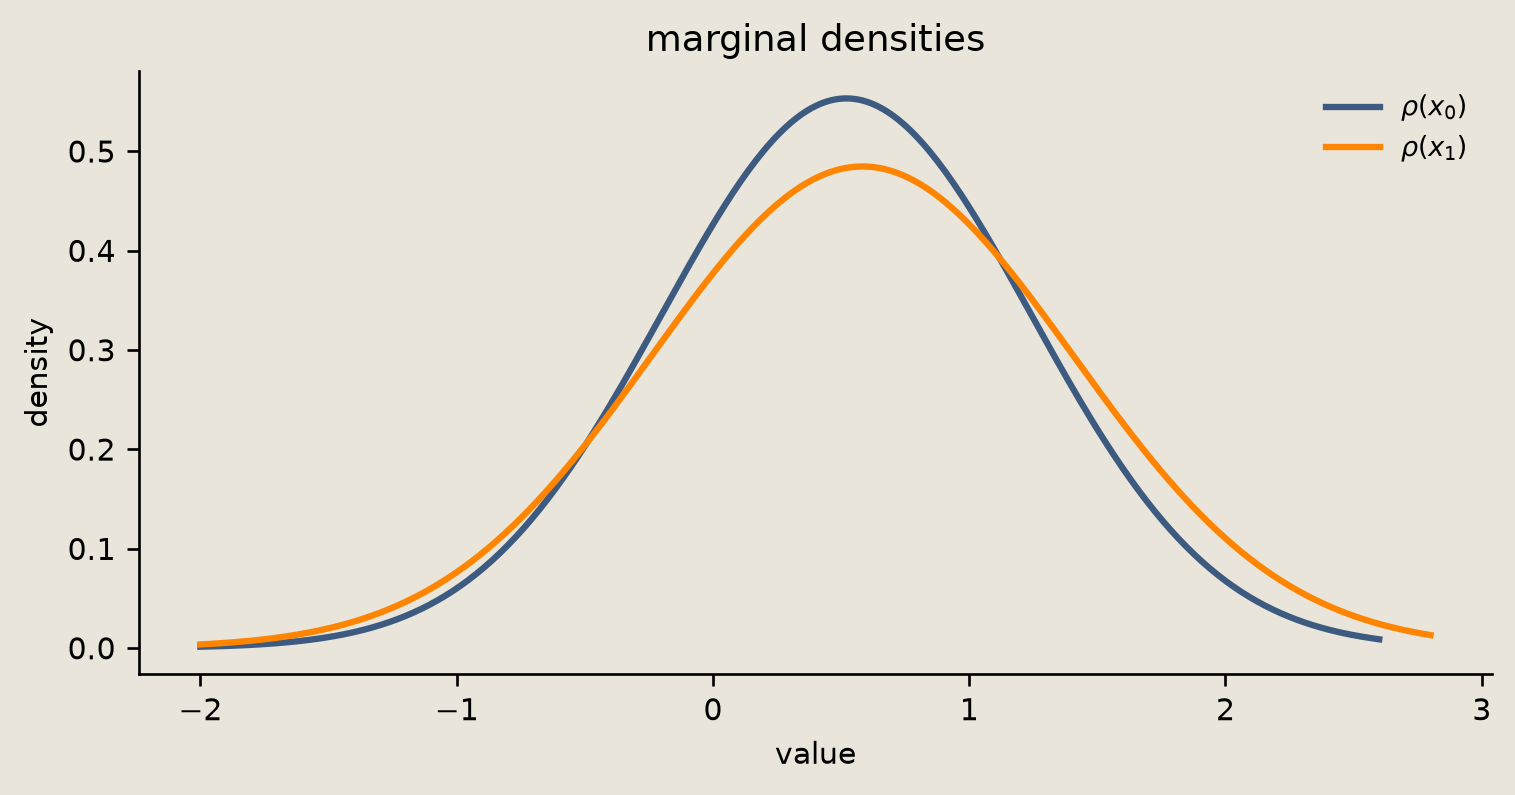

In [25]:
fig = P_fld.prior_marginals(prior, figsize=(6.2, 3.2))
savefig(fig, "10_pmode_prior_marginals")

The marked mean in the joint plot and the two one-dimensional marginals come from one propagated mean and covariance, with no samples underneath.

## Conditioning on one site

The `Mix` gate introduced off-diagonal covariance between site 0 and site 1, so the two sites are correlated, and an observation of one site changes the distribution of the other.

Given a value $y_1$ for site 1, the Gaussian posterior on site 0 is the Schur complement (the standard formula for the conditioned Gaussian):

$$
\mu_{0\mid 1} = \mu_0 + \Sigma_{01}\Sigma_{11}^{-1}(y_1 - \mu_1),
\qquad
\Sigma_{0\mid 1} = \Sigma_{00} - \Sigma_{01}\Sigma_{11}^{-1}\Sigma_{10}.
$$

The `condition` method of `AffineGaussianSimulator` computes this closed-form posterior. We condition on the observed value $y_1 = 0.35$, the same value the later figures mark as `Y_OBS`. Because the sites are correlated, the posterior variance on site 0 is smaller than its prior value.

In [26]:
# Condition on site 1 and ask for the posterior over site 0.
posterior = affine_sim.condition(
    affine_compiled,
    observations={1: jnp.array([0.35])},
    initial_continuous=jnp.zeros(2),
    query_sites=[0],
)

In [27]:
prior_mu0 = float(prior.mean[0])
prior_sig0 = float(jnp.sqrt(prior.covariance[0, 0]))
post_mu0 = float(posterior.mean[0])
post_sig0 = float(jnp.sqrt(posterior.covariance[0, 0]))

print(f"prior   site 0:  mean = {prior_mu0:.4f},  std = {prior_sig0:.4f}")
print(f"post    site 0:  mean = {post_mu0:.4f},  std = {post_sig0:.4f}")

prior   site 0:  mean = 0.5208,  std = 0.7213
post    site 0:  mean = 0.3612,  std = 0.4515


In [28]:
assert float(posterior.covariance[0, 0]) < float(
    prior.covariance[0, 0]
), "posterior variance did not narrow"

## Monte Carlo comparison

The analytic moments are exact, so they give us a clean reference.

`HybridPCircuit.sample_multiple` draws full trajectories. As the sample count grows, the empirical mean and covariance approach the analytic moments.

We draw 20,000 samples so the empirical covariance is within the Monte Carlo tolerance checked below at this seed.


In [29]:
num_samples = 20_000
initial_state = {
    "discrete": jnp.array([], dtype=jnp.int32),
    "continuous": jnp.zeros(2),
}

In [30]:
samples = step.sample_multiple(
    jax.random.key(SEED), initial_state, step_thetas, n_samples=num_samples
)["continuous"]
samples_np = np.asarray(samples)

In [31]:
sample_mean = jnp.mean(samples, axis=0)
sample_cov = jnp.asarray(np.cov(samples_np.T))

mean_error = float(jnp.max(jnp.abs(sample_mean - prior.mean)))
cov_error = float(jnp.max(jnp.abs(sample_cov - prior.covariance)))

print(f"analytic mean:  {np.array(prior.mean).tolist()}")
print(f"sample mean:    {np.array(sample_mean).tolist()}")
print(f"max mean error: {mean_error:.4f}")
print(f"max cov error:  {cov_error:.4f}")

analytic mean:  [0.5207920670509338, 0.5835674405097961]
sample mean:    [0.5317030549049377, 0.5874403119087219]
max mean error: 0.0109
max cov error:  0.0021


In [32]:
prior_cov_np = np.asarray(prior.covariance)
mean_atol = 6.0 * np.sqrt(float(np.max(np.diag(prior_cov_np))) / num_samples)
cov_entry_se = np.sqrt(
    (prior_cov_np**2 + np.outer(np.diag(prior_cov_np), np.diag(prior_cov_np)))
    / (num_samples - 1)
)
cov_atol = 6.0 * float(np.max(cov_entry_se))
# why: Monte Carlo moment error shrinks as 1/sqrt(num_samples).
np.testing.assert_allclose(np.array(sample_mean), np.array(prior.mean), atol=mean_atol)
np.testing.assert_allclose(np.array(sample_cov), prior_cov_np, atol=cov_atol)



In [33]:
exact_vals = np.array(
    [
        float(prior.mean[0]),
        float(prior.mean[1]),
        float(prior.covariance[0, 0]),
        float(prior.covariance[0, 1]),
        float(prior.covariance[1, 1]),
    ]
)
sample_vals = np.array(
    [
        float(sample_mean[0]),
        float(sample_mean[1]),
        float(sample_cov[0, 0]),
        float(sample_cov[0, 1]),
        float(sample_cov[1, 1]),
    ]
)
labels = [r"$\mu_0$", r"$\mu_1$", r"$\Sigma_{00}$", r"$\Sigma_{01}$", r"$\Sigma_{11}$"]



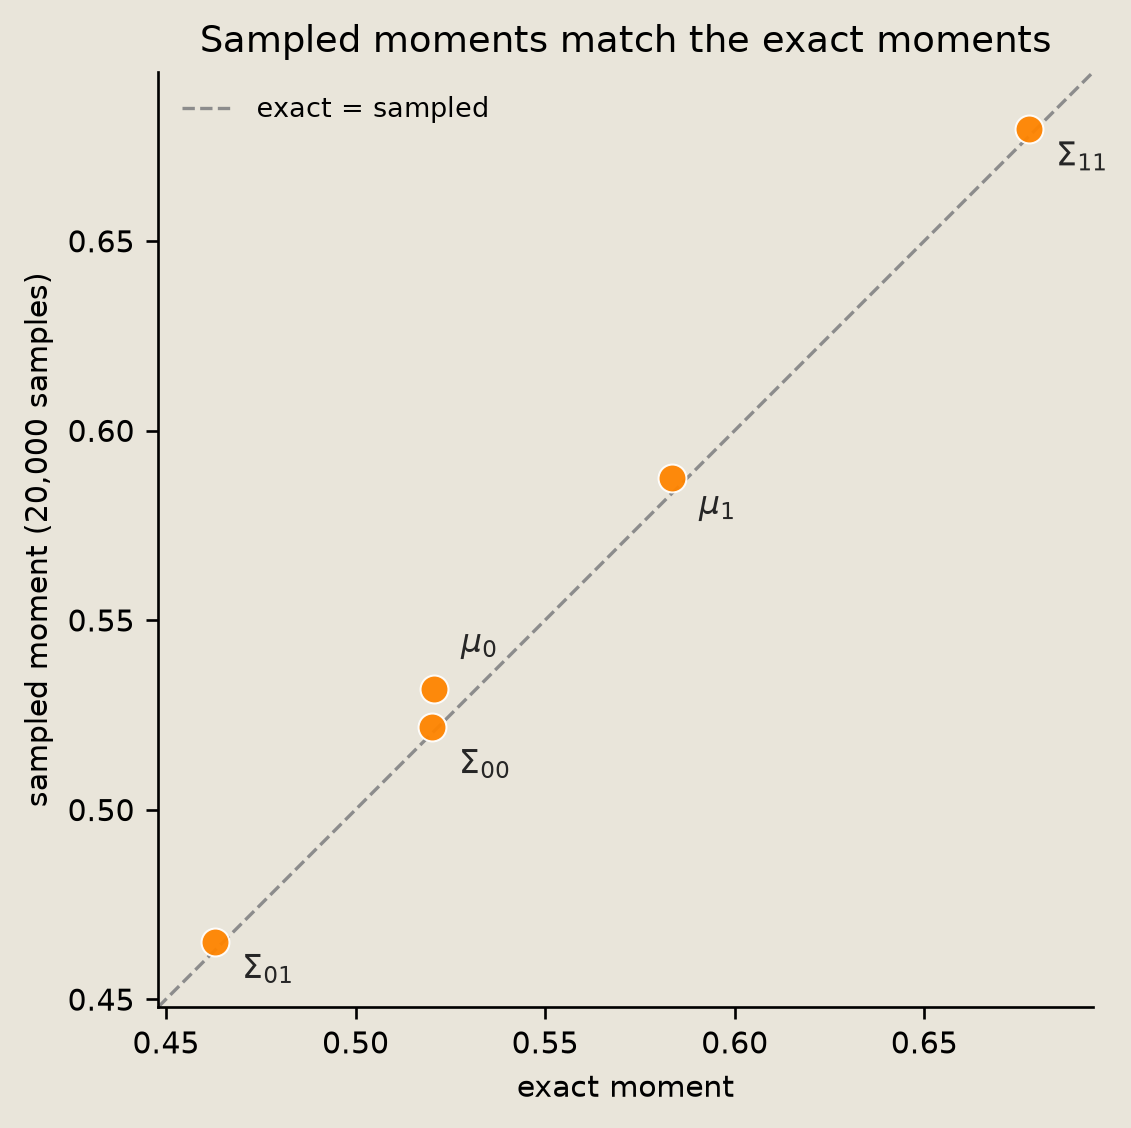

In [34]:
fig = P_samp.moment_parity(exact_vals, sample_vals, labels, num_samples, figsize=(4.6, 4.6))
savefig(fig, "10_pmode_gaussian_moment_parity")


The parity plot puts the two means and three independent covariance entries ($\Sigma_{00}$, $\Sigma_{01}$, and $\Sigma_{11}$) close to the diagonal.

## Comparing the posterior to samples

The sample-cloud figure shows the prior mean and a dashed line at the observation $y_1 = 0.35$.

The posterior figure shows the analytic prior and posterior densities over site 0, together with a histogram of trajectories whose site 1 value landed in a narrow band around the observation.

In [35]:
BAND = 0.15
Y_OBS = 0.35


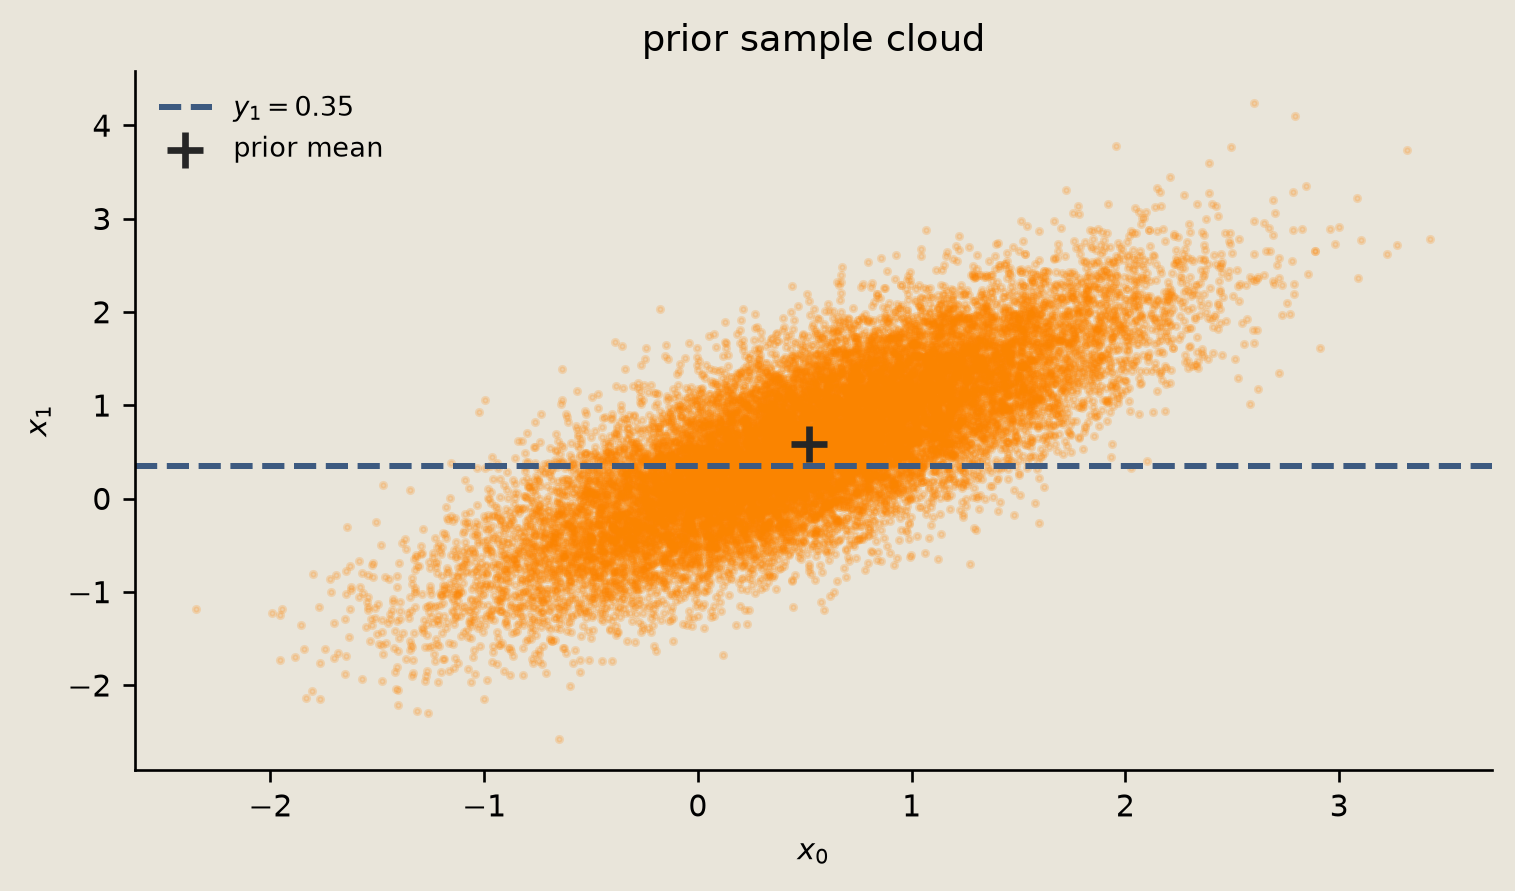

In [36]:
fig = P_fld.conditioning_cloud(samples_np, Y_OBS, prior, figsize=(6.2, 3.6))
savefig(fig, "10_pmode_gaussian_conditioning_cloud")

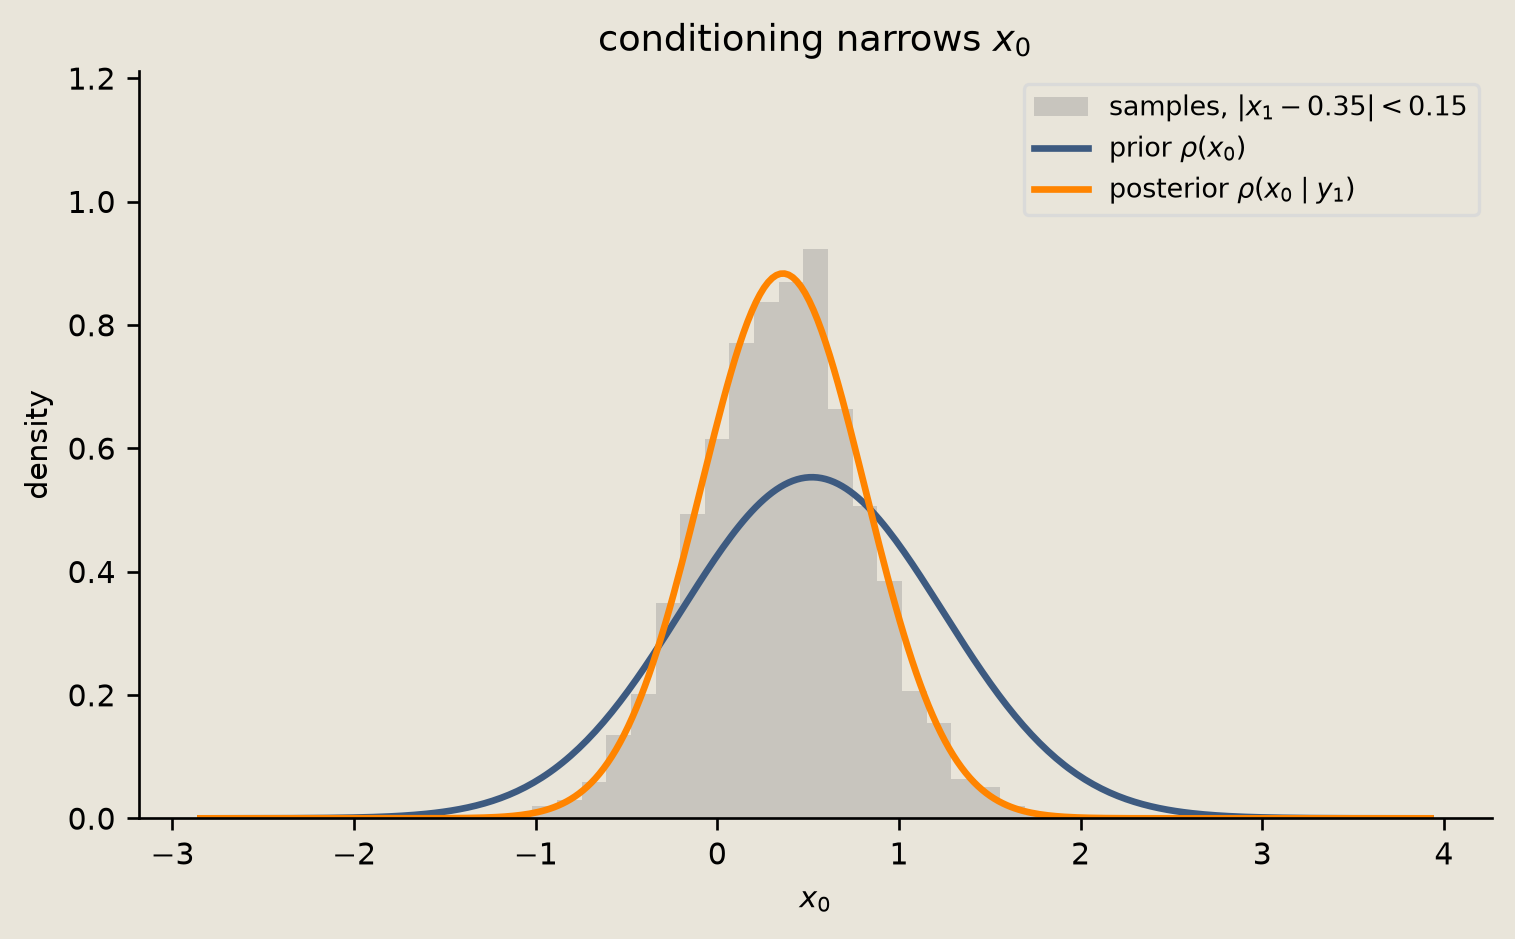

In [37]:
fig = P_fld.conditioning_posterior(
    prior,
    posterior,
    samples_np,
    Y_OBS,
    BAND,
    figsize=(6.2, 3.8),
)
savefig(fig, "10_pmode_gaussian_conditioning_posterior")


The figures show that conditioning on site 1 narrows the posterior distribution for site 0.

## Mixtures: leaving the Gaussian family

Pure affine Gaussian gates can only produce Gaussians.

`MixtureGaussianGate` uses a **pdit** (a $d$-state discrete site) to select one of `K` Gaussian components. The gate adds the selected component's mean and Gaussian noise to the current continuous value. Starting from $x=0$, marginalizing the control gives a mixture density:

$$
\rho(x) = \sum_{k} \pi_k\,\mathcal{N}(x;\, \mu_k,\, \sigma_k^2),
$$

which is no longer Gaussian.

The notebook helper `plot_mixture_density` (from `examples/helpers/_plots_fields.py`) evaluates the exact PDF from the gate's `means` and `log_vars` together with the separate control `weights` over a grid. `MixtureGaussianGate` itself only carries `means` and `log_vars`; the component weights are a separate control distribution, which we encode in this binary pdit demonstration through `PditShift`, a gate that flips the control from 0 to 1 with probability set by its log-odds `theta`. The sampler below draws the pdit control with the declared weights, then lets `MixtureGaussianGate` draw the component-conditioned Gaussian sample.

This is the non-Gaussian primitive used by the continuous arc. The full process is developed in [`13_regime_switching_diffusion.ipynb`](13_regime_switching_diffusion.ipynb).


In [38]:
mix_means = jnp.array([[-1.5], [1.5]])
mix_log_vars = jnp.log(jnp.array([[0.25], [0.25]]))
mix_weights = jnp.array([0.5, 0.5])

In [39]:
n_components = mix_means.shape[0]
mog_gate = MixtureGaussianGate(
    sites=(0, 0),  # first entry: discrete control site; second: continuous site
    dims=(1,),
    num_components=n_components,
)
mog_theta = {"means": mix_means, "log_vars": mix_log_vars}



In [40]:
mix_weights_np = np.asarray(mix_weights, dtype=float)
if n_components != 2 or mix_weights_np.shape != (2,):
    raise ValueError("this PditShift demo samples a binary mixture; use PditCycle or categorical controls for K > 2")
np.testing.assert_allclose(mix_weights_np.sum(), 1.0)
if np.any(mix_weights_np <= 0.0):
    raise ValueError("PditShift log-odds need positive binary mixture weights")



In [41]:
# why: starting at control 0, PditShift reaches control 1 with probability mix_weights[1].
control_gate = PditShift(sites=0, dims=n_components)
control_theta = jnp.array([np.log(mix_weights_np[1] / mix_weights_np[0])], dtype=mix_means.dtype)


In [42]:
def sample_mixture(
    mog_gate,
    mog_theta,
    control_gate,
    control_theta,
    seed,
    num_samples=16_000,
):
    """Sample the control-then-mixture circuit; return continuous draws and control bits."""
    mix_circuit = HybridPCircuit([control_gate, mog_gate])
    init_state = {
        "discrete": jnp.array([0], dtype=jnp.int32),
        "continuous": jnp.zeros(1),
    }
    out = mix_circuit.sample_multiple(
        jax.random.key(seed),
        init_state,
        [control_theta, mog_theta],
        n_samples=num_samples,
    )
    return np.asarray(out["continuous"])[:, 0], np.asarray(out["discrete"])[:, 0]


In [43]:
num_mixture_samples = 16_000
mix_all, mix_labels = sample_mixture(
    mog_gate,
    mog_theta,
    control_gate,
    control_theta,
    SEED + 500,
    num_samples=num_mixture_samples,
)

mix_empirical_weights = np.bincount(mix_labels, minlength=n_components) / num_mixture_samples
weight_atol = 4.0 * np.sqrt(
    float(np.max(mix_weights_np * (1.0 - mix_weights_np))) / num_mixture_samples
)
print(f"drawn pdit weights: {mix_empirical_weights.round(3).tolist()}")
np.testing.assert_allclose(mix_empirical_weights, mix_weights_np, atol=weight_atol)


drawn pdit weights: [0.505, 0.495]


In [44]:
mix_component_means = np.asarray(mix_means).reshape(-1)
mix_component_vars = np.exp(np.asarray(mix_log_vars).reshape(-1))
mix_mean_exact = float(np.dot(mix_weights_np, mix_component_means))
mix_var_exact = float(
    np.dot(mix_weights_np, mix_component_vars + mix_component_means**2)
    - mix_mean_exact**2
)
mean_atol = 4.0 * np.sqrt(mix_var_exact / num_mixture_samples)
var_rtol = 6.0 * np.sqrt(2.0 / (num_mixture_samples - 1))
# why: these are Monte Carlo checks on a sampled pdit control.
np.testing.assert_allclose(np.mean(mix_all), mix_mean_exact, atol=mean_atol)
np.testing.assert_allclose(np.var(mix_all), mix_var_exact, rtol=var_rtol)

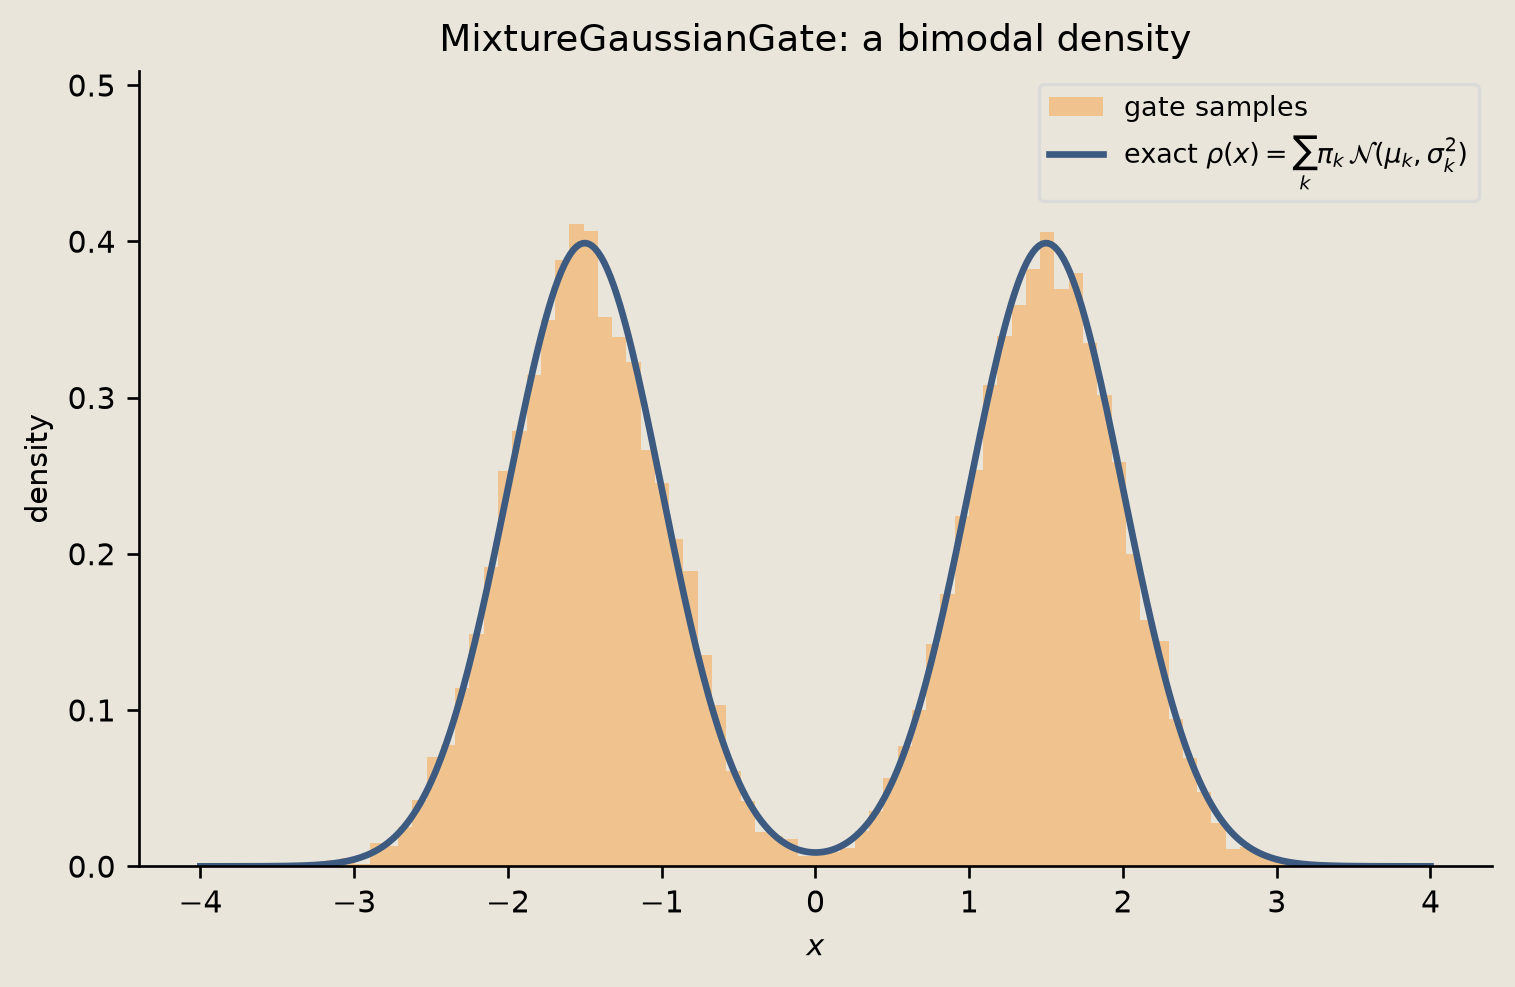

In [45]:
fig = P_fld.plot_mixture_density(
    mix_all, mix_means, mix_log_vars, mix_weights, figsize=(6.2, 4.0)
)
savefig(fig, "10_pmode_mixture_density")

The figure shows a bimodal histogram matching the exact two-component mixture density.

## Conclusion

We built the pmode Gaussian gate set and checked it from a few angles.

`AffineGaussianGate` is the general continuous gate. The `Displace`, `Scale`, `Mix`, and `Diffuse` gates are specialized affine Gaussian maps for common cases. Because stacks of these gates remain affine Gaussian, `AffineGaussianSimulator` can propagate moments exactly without sampling.

The sample-based checks with `HybridPCircuit.sample_multiple` land close to the analytic moments. The `condition` method gives the closed-form Gaussian posterior, and conditioning on one correlated site narrows the other. Finally, `MixtureGaussianGate` adds a discrete control and produces a mixture density, so the model can leave the Gaussian family.

To continue, see [`11_gaussian_hierarchical_ssm.ipynb`](11_gaussian_hierarchical_ssm.ipynb) for the Kalman and Rauch-Tung-Striebel (RTS) smoother, and [`13_regime_switching_diffusion.ipynb`](13_regime_switching_diffusion.ipynb) for the regime-switching mixture process.